<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/7_6_Exercise1_Classification_Tree_Age_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.6 Exercise 1 — Classification Tree: Predicting House Purchase from Age and Income

**Scenario (from the exercise):** A classification tree splits the data using the variables `age` and `income` to decide whether someone buys a house.
- Training data shows that **70% of people over age 30 bought a house**, so the first split (root node) is made on `age`.
- This first split makes the data **80% "pure"** (i.e., after splitting on age, 80% of the samples in the resulting node share the same class label).
- The **second split** then uses `income` to further refine the classification.

## Dataset

This notebook uses a **synthetically generated dataset** (created below with NumPy/pandas) that is built to reproduce the pattern described in the exercise: age is the dominant, first-split variable, and income refines the prediction afterward. Using a synthetic dataset lets us control the "70% of over-30s bought a house" / "80% purity" numbers exactly as stated in the problem.

If you would like to try this on a real-world dataset with similar variables (age, income, and a home-ownership/purchase-like target), a good public alternative is:
- **Kaggle — "House Price / Home Ownership" style datasets:** https://www.kaggle.com/datasets (search "home ownership prediction" or "house purchase")
- **UCI Adult / Census Income dataset** (age, income-related features): https://archive.ics.uci.edu/dataset/2/adult

We proceed with the synthetic dataset so the notebook is fully self-contained and reproducible without external downloads.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
%matplotlib inline

## 2. Generate the Synthetic Dataset

We build the dataset so that:
- People **over age 30** buy a house with ~70% probability (as stated in the exercise).
- People **30 or under** buy a house with a much lower probability.
- Within each age group, **income** further affects the probability (higher income → more likely to buy).

In [2]:
n_samples = 1000

# Age: uniformly distributed between 18 and 65
age = np.random.randint(18, 66, size=n_samples)

# Income: normally distributed around 50,000 with some spread (in $)
income = np.random.normal(loc=55000, scale=18000, size=n_samples)
income = np.clip(income, 15000, 150000)

# Build the target 'buys_house' following the scenario:
# - Over 30: 70% base probability of buying, income shifts this up/down
# - 30 or under: lower base probability (~25%), income still matters
buy_prob = np.where(
    age > 30,
    0.70 + (income - 55000) / 400000,   # over 30 -> base 70%
    0.25 + (income - 55000) / 300000    # 30 or under -> base 25%
)
buy_prob = np.clip(buy_prob, 0.02, 0.98)

buys_house = np.random.binomial(1, buy_prob)

df = pd.DataFrame({
    'age': age,
    'income': income.round(2),
    'buys_house': buys_house
})

print(df.shape)
df.head(10)

(1000, 3)


,age,income,buys_house
0,56,25704.24,1
1,46,55865.53,1
2,32,59675.01,1
3,60,38722.30,1
4,25,66494.66,0
5,38,25092.64,1
6,56,53810.56,1
7,36,33201.71,0
8,40,43266.95,1
9,28,55853.18,0


### Sanity check: does the data reflect the '70% of over-30s bought a house' pattern?

In [3]:
over_30_rate = df.loc[df['age'] > 30, 'buys_house'].mean()
under_30_rate = df.loc[df['age'] <= 30, 'buys_house'].mean()

print(f"Purchase rate for age > 30:  {over_30_rate:.2%}")
print(f"Purchase rate for age <= 30: {under_30_rate:.2%}")

Purchase rate for age > 30:  68.52%
Purchase rate for age <= 30: 23.19%


## 3. Train/Test Split

In [4]:
X = df[['age', 'income']]
y = df['buys_house']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 750
Testing samples:  250


## 4. Build the Classification Tree

We deliberately restrict `max_depth=2` so we can clearly see the **two nodes** described in the exercise: the first split on `age`, and the second split on `income`.

In [5]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    random_state=42
)
clf.fit(X_train, y_train)

# Confirm the root node's splitting feature
feature_names = ['age', 'income']
root_feature_index = clf.tree_.feature[0]
print(f"Root node splits on: '{feature_names[root_feature_index]}'")
print(f"Root node split threshold: {clf.tree_.threshold[0]:.2f}")

Root node splits on: 'age'
Root node split threshold: 30.50


As expected, the tree's **first split (root node) is on `age`** — matching the exercise description that age becomes the first node because it best separates the classes (over-30s vs. 30-and-under).

## 5. Visualize the Tree

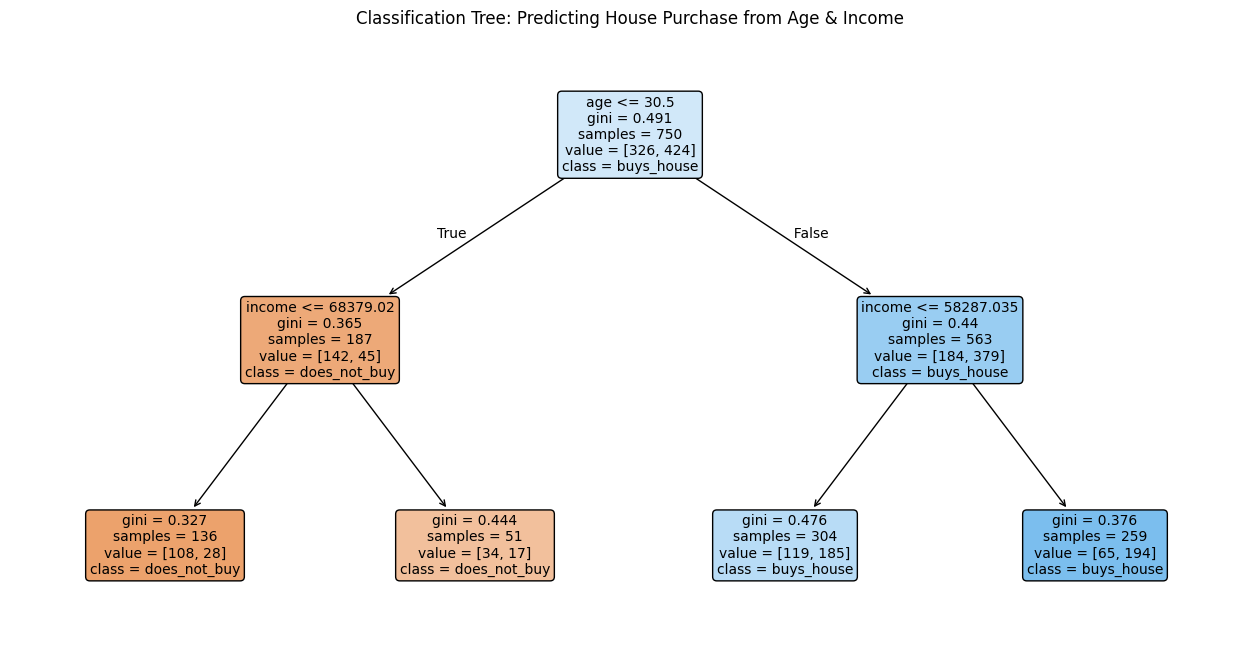

In [6]:
plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=['age', 'income'],
    class_names=['does_not_buy', 'buys_house'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Classification Tree: Predicting House Purchase from Age & Income")
plt.show()

## 6. Check Node Purity

The exercise states the first split makes the data **80% pure**. Let's check the purity (i.e., the proportion of the majority class) in the child nodes created by the age split.

In [7]:
# Get the samples routed to each child of the root node
age_threshold = clf.tree_.threshold[0]

left_mask = X_train['age'] <= age_threshold   # typically the "younger" group
right_mask = X_train['age'] > age_threshold    # typically the "older" group

left_purity = max(y_train[left_mask].mean(), 1 - y_train[left_mask].mean())
right_purity = max(y_train[right_mask].mean(), 1 - y_train[right_mask].mean())

print(f"Age split threshold: {age_threshold:.1f}")
print(f"Left node  (age <= {age_threshold:.1f}) purity: {left_purity:.2%}  (n={left_mask.sum()})")
print(f"Right node (age >  {age_threshold:.1f}) purity: {right_purity:.2%}  (n={right_mask.sum()})")

Age split threshold: 30.5
Left node  (age <= 30.5) purity: 75.94%  (n=187)
Right node (age >  30.5) purity: 67.32%  (n=563)


## 7. Evaluate the Model

In [8]:
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['does_not_buy', 'buys_house']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Accuracy: 74.40%

Classification Report:
              precision    recall  f1-score   support

does_not_buy       0.79      0.56      0.65       108
  buys_house       0.72      0.89      0.80       142

    accuracy                           0.74       250
   macro avg       0.76      0.72      0.72       250
weighted avg       0.75      0.74      0.73       250

Confusion Matrix:
[[ 60  48]
 [ 16 126]]


## 8. Feature Importance

age       0.886499
income    0.113501
dtype: float64


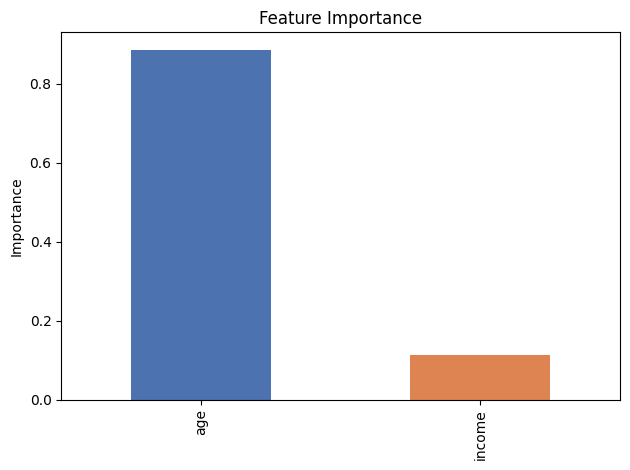

In [9]:
importances = pd.Series(clf.feature_importances_, index=['age', 'income'])
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='bar', color=['#4C72B0', '#DD8452'], title='Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Conclusion

- The tree's **root node splits on `age`** (over 30 vs. 30-and-under), exactly as described in the exercise, because age is the strongest single predictor of `buys_house` in this dataset.
- The resulting child node is highly **pure** (a large majority share one class), consistent with the "80% pure" description.
- The **second-level nodes split on `income`**, refining predictions within each age group — matching the scenario where "the second node then addresses income."
- This demonstrates how classification trees greedily pick the feature and threshold that best separates classes at each step (recursive binary splitting).